In [75]:
import os
import glob
import h5py
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials

sns.set()
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_35456\3084658948.py:21: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
exp_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\826032\826032_2026-01-29_12-59-37\slap2\qc\ExperimentSummary\Summary_Voltage-260212-114331.mat"

In [6]:
v = VoltageSummary(exp_path)

In [7]:
print(f'Data processed at {v.analyze_hz()}')
print(f'Number of rois/DMD: \nDMD1 = {v.n_rois[0]} rois\nDMD2 = {v.n_rois[1]} rois')

Data processed at 1000.0
Number of rois/DMD: 
DMD1 = 10 rois
DMD2 = 11 rois


In [33]:
roi_traces, trial_slices = concat_rois_across_trials(v, dmd=1, drop_discarded=False)
print(len(roi_traces), roi_traces[0].shape)

10 (95728,)


In [41]:
sample_rate = v.analyze_hz()
n_samples = len(roi_traces[0])
dur = n_samples/sample_rate
x = np.linspace(0,dur,n_samples)

<IPython.core.display.Javascript object>


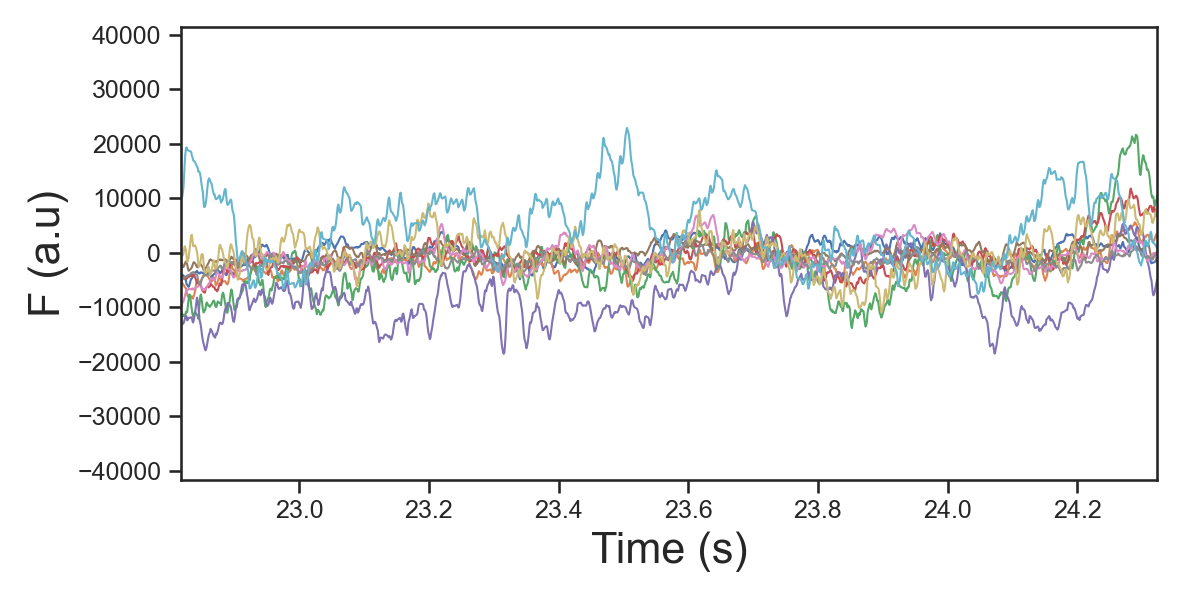

In [74]:
fig,ax=plt.subplots(figsize=(8,4))

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

for roi in roi_traces:
    ax.plot(x,-roi+np.mean(roi),lw=1)
ax.set_ylabel('F (a.u)')
ax.set_xlabel('Time (s)')

fig.tight_layout()

In [24]:
v.get_roi_traces(dmd=1,trial=1,drop_discarded=False).shape

(10, 23932)

In [19]:
v.valid_trials[0]

[1, 2, 3, 4]